# A nasty integral
Using Monte Carlo integration, check that


- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given N, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks very accurate! And if N is small?)
- How does the distribution change if N increases?
(Hint: think about sample mean and sample variance)

In [143]:
import numpy as np
import pylab as plt
from scipy.stats import norm
import matplotlib.pyplot as plt

$f(x) = x^3$, $\quad p(x) = \text{exp}(\frac{-x^2}{2\sigma^2})\frac{1}{\sqrt{2\pi\sigma^2}}$

- Campiono p(x) 
- Integrale = $\sqrt(2\pi\sigma^2)*\frac{1}{2}*\text{media di f(x)}$
- $\frac{1}{2}$ perché integro da 0 a inf (mentre la gaussiana fa 1 per $\int_{-\inf}^{\inf}$

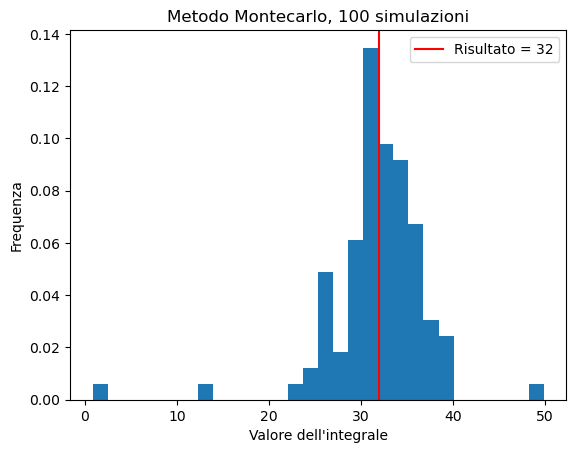

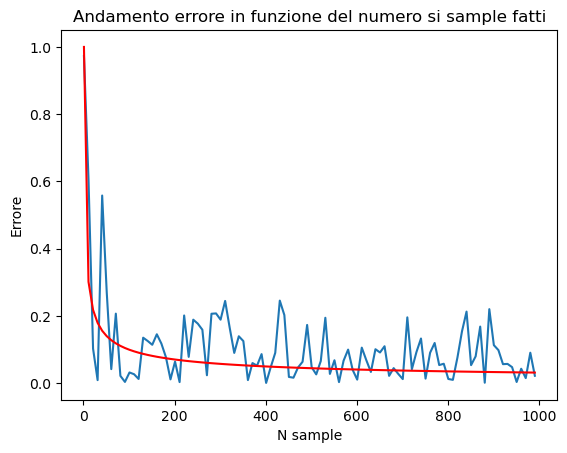

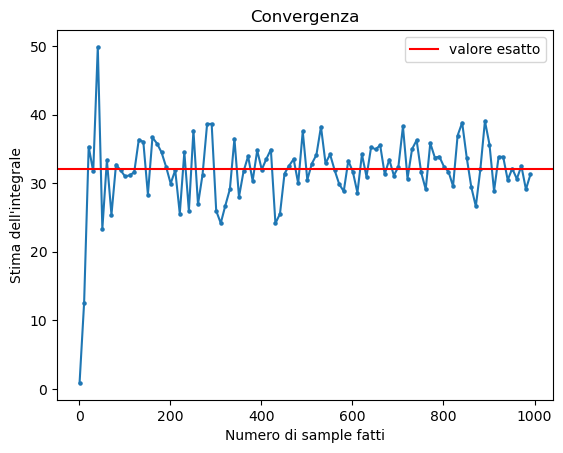

In [116]:
sigma = 2
ris = 2*sigma**4
result = []
err = []


simulazioni = 100
sample = np.arange(1,1000,10)     


for j in sample:
    for i in range(simulazioni):
        xi = np.abs(np.random.normal(0, sigma, j))
    integral = np.sqrt(2*np.pi*sigma**2) * np.mean(xi**3)/2
    result.append(integral)
   
    error = np.abs(integral - ris)/ris
    err.append(error)
  

plt.figure()
plt.hist(result, bins=30, density = True)
plt.axvline(ris, color =  'red', label = f'Risultato = {ris}')
plt.title(f'Metodo Montecarlo, {simulazioni} simulazioni')
plt.xlabel("Valore dell'integrale")
plt.ylabel('Frequenza')
plt.legend()

#errore
plt.figure()
plt.plot(sample, err)
plt.plot(sample, np.sqrt(1/sample), color = 'red')
#plt.loglog()
plt.title('Andamento errore in funzione del numero si sample fatti')
plt.xlabel("N sample")
plt.ylabel("Errore")


#convergenza
plt.figure()
plt.scatter(sample, result, s=5)
plt.plot(sample, result)
plt.axhline(ris, color='red', label='valore esatto')
plt.title('Convergenza')
plt.xlabel("Numero di sample fatti")
plt.ylabel("Stima dell'integrale")
plt.legend()

plt.show()

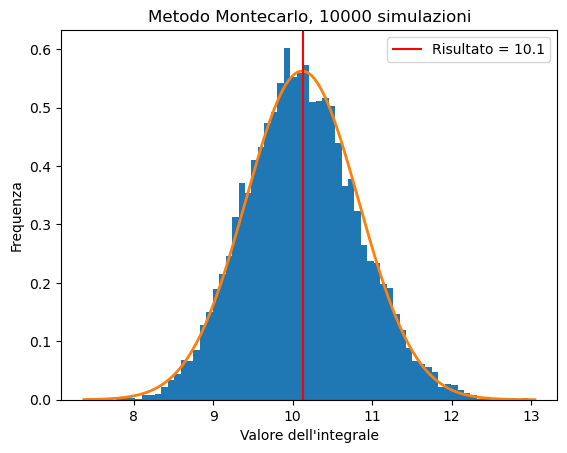

In [158]:
sigma = 1.5
ris = 2*sigma**4
stima = []

simulazioni = 10000 

sample = 1000  #fisso numero di sample

for i in range(simulazioni): #faccio tante simulazioni Montecarlo
    xi = np.abs(np.random.normal(0, sigma, sample))
    integral = np.sqrt(2*np.pi*sigma**2) * np.mean(xi**3)/2
    stima.append(integral)

mean = np.mean(stima)        # stima della media μ
std = np.std(stima, ddof=1)

x = np.linspace(min(stima), max(stima), 1000)
gauss = norm.pdf(x, loc=mean, scale=std)


plt.figure()
plt.hist(stima, bins=70, density = True)
plt.plot(x, gauss, lw=2)
plt.axvline(ris, color = 'red', label = f'Risultato = {ris:.1f}')
plt.title(f'Metodo Montecarlo, {simulazioni} simulazioni')
plt.xlabel("Valore dell'integrale")
plt.ylabel('Frequenza')
plt.legend()